# Instacart A/B Test: Does a Discount Badge Increase Reorder Rates?

I built this analysis to simulate a real-world A/B test using Instacart's public dataset (3.4M orders, 200K users).

The business question I'm trying to answer:
> *If we show users a discount badge on product cards, does it meaningfully increase reorder rates — and does the revenue justify the discount cost?*

This is exactly the kind of experiment food delivery platforms like Coupang Eats or DoorDash run constantly. I wanted to go beyond a basic p-value and build a complete experimentation pipeline the way a senior DS would actually do it.

**My workflow:**
1. Load data via Kaggle API
2. EDA — understand the data before touching the experiment
3. SRM check — validate randomization is actually working
4. Normality check — decide which statistical test is appropriate
5. Mann-Whitney U (primary) + t-test (secondary)
6. Cohen's d — measure practical effect size, not just statistical significance
7. Bootstrap confidence interval — no distribution assumptions needed
8. Power analysis — show I designed the experiment correctly upfront
9. Multiple testing correction — account for testing multiple metrics at once
10. Novelty effect check — verify the effect holds over time
11. Logistic regression + pseudo R² — model which users respond most
12. Segment analysis + business impact

---
## 1. Imports

I'm pulling in the standard stats/viz stack plus `statsmodels` for the logistic regression and `kagglehub` to load the dataset directly without downloading anything locally.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, shapiro, ttest_ind
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries loaded.')

All libraries loaded.


---
## 2. Load Data

I'm loading directly from Kaggle using `kagglehub` — no manual download needed. The three files I need are:

- `orders.csv` — every order ever placed, with user ID, day/time, and how many days since the previous order
- `order_products__prior.csv` — every product in every order, including a `reordered` flag (1 = bought before, 0 = new item). This is my main metric.
- `products.csv` — product names, used for context

In [2]:
path = kagglehub.dataset_download('psparks/instacart-market-basket-analysis')

orders         = pd.read_csv(f'{path}/orders.csv')
order_products = pd.read_csv(f'{path}/order_products__prior.csv')
products       = pd.read_csv(f'{path}/products.csv')

print(f'orders:         {orders.shape[0]:,} rows, {orders.shape[1]} columns')
print(f'order_products: {order_products.shape[0]:,} rows, {order_products.shape[1]} columns')
print(f'products:       {products.shape[0]:,} rows, {products.shape[1]} columns')

orders:         3,421,083 rows, 7 columns
order_products: 32,434,489 rows, 4 columns
products:       49,688 rows, 4 columns


---
## 3. EDA — Understanding the Data Before Running Any Test

My rule: never touch an experiment until I understand the raw data. EDA helps me catch data quality issues early and build intuition about how users actually behave.

I want to know:
- When are users most active?
- What does the baseline reorder rate look like?
- Are there any data artifacts I need to flag?
- How loyal are users — do they come back often or is it mostly one-time shoppers?

In [4]:
# basic overview of the orders table
print('=== first 5 rows ===')
print(orders.head())
print()

print('=== column info ===')
orders.info()
print()

print('=== missing values ===')
print(orders.isnull().sum())
print()

# days_since_prior_order is null for a user's very first order
# that makes sense — there's no previous order to measure from
print('=== summary statistics ===')
print(orders.describe().round(2))

=== first 5 rows ===
   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                    29.0  
4                    28.0  

=== column info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            i

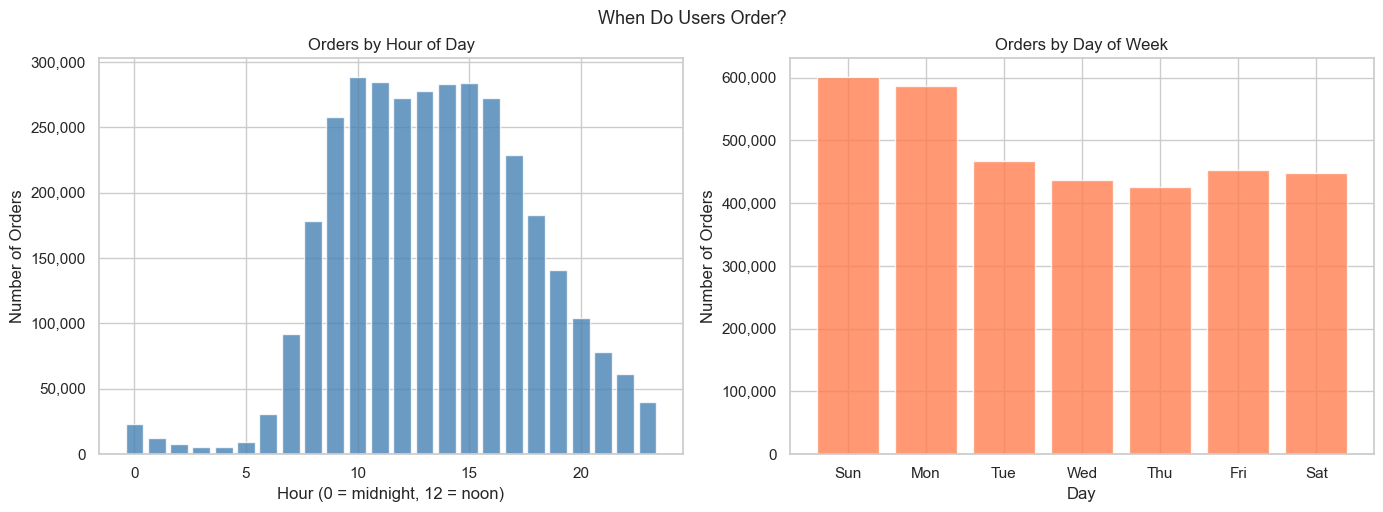

Peak hour: 10:00
Peak day: Sun


In [5]:
# when do users order?
# this tells me about user activity patterns — useful context for interpreting test results

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hour_counts = orders['order_hour_of_day'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color='steelblue', alpha=0.8)
axes[0].set_title('Orders by Hour of Day')
axes[0].set_xlabel('Hour (0 = midnight, 12 = noon)')
axes[0].set_ylabel('Number of Orders')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

day_labels = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
day_counts = orders['order_dow'].value_counts().sort_index()
axes[1].bar(day_labels, day_counts.values, color='coral', alpha=0.8)
axes[1].set_title('Orders by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Orders')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.suptitle('When Do Users Order?', fontsize=13, y=1.02)
plt.show()

print(f'Peak hour: {hour_counts.idxmax()}:00')
print(f'Peak day: {day_labels[day_counts.idxmax()]}')

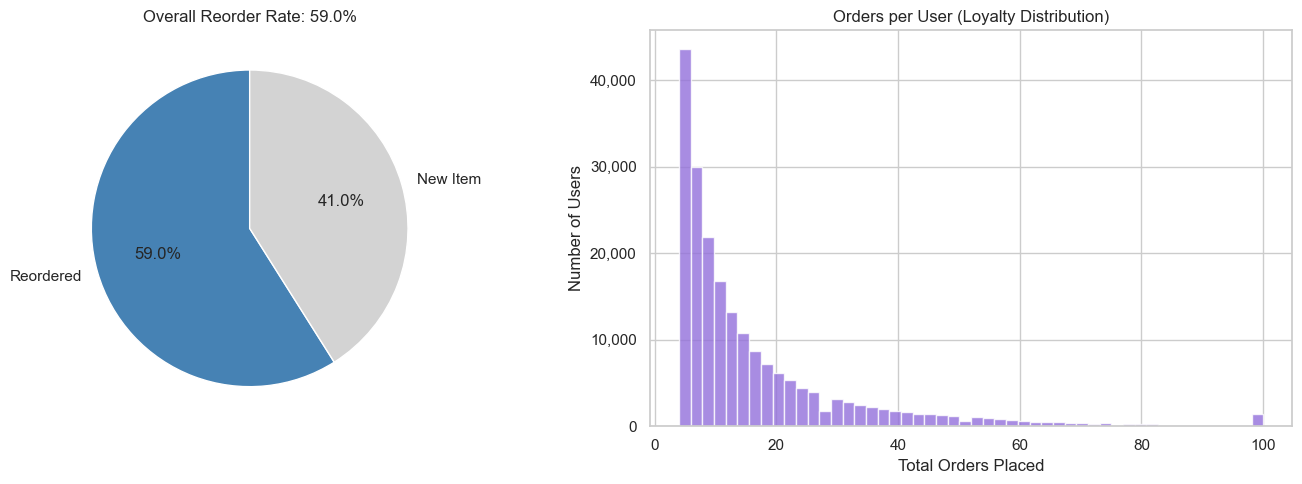

Overall reorder rate: 59.0%
Avg orders per user: 16.6
Median orders per user: 10


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# overall reorder rate — this is my baseline before splitting into groups
# the reordered column is 1 if the item was bought before, 0 if it's new
# mean of 0s and 1s = the proportion of reordered items
reorder_rate_overall = order_products['reordered'].mean()
axes[0].pie(
    [reorder_rate_overall, 1 - reorder_rate_overall],
    labels=['Reordered', 'New Item'],
    colors=['steelblue', 'lightgray'],
    autopct='%1.1f%%', startangle=90
)
axes[0].set_title(f'Overall Reorder Rate: {reorder_rate_overall:.1%}')

# orders per user — measures loyalty and how much history each user has
orders_per_user = orders.groupby('user_id')['order_number'].max()
axes[1].hist(orders_per_user, bins=50, color='mediumpurple', alpha=0.8, edgecolor='white')
axes[1].set_title('Orders per User (Loyalty Distribution)')
axes[1].set_xlabel('Total Orders Placed')
axes[1].set_ylabel('Number of Users')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print(f'Overall reorder rate: {reorder_rate_overall:.1%}')
print(f'Avg orders per user: {orders_per_user.mean():.1f}')
print(f'Median orders per user: {orders_per_user.median():.0f}')

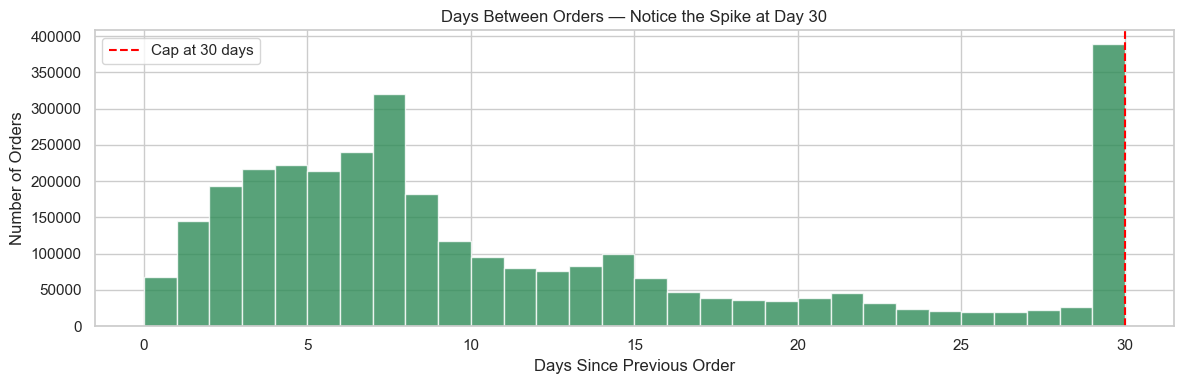

Orders recorded as exactly 30 days: 369,323 (11.5% of repeat orders)
These include all gaps >= 30 days — the true distribution is right-skewed further than it appears.


In [7]:
# days between orders — one of my favorite charts because it reveals a data quality issue
repeat_orders = orders[orders['days_since_prior_order'].notna()]

plt.figure(figsize=(12, 4))
plt.hist(repeat_orders['days_since_prior_order'], bins=30,
         color='seagreen', alpha=0.8, edgecolor='white')
plt.axvline(30, color='red', linestyle='--', linewidth=1.5, label='Cap at 30 days')
plt.title('Days Between Orders — Notice the Spike at Day 30')
plt.xlabel('Days Since Previous Order')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.show()

# I always flag this in any analysis using this dataset
# the spike at 30 is NOT real user behavior — it's a data encoding decision by Instacart
# they capped the column at 30, so all gaps > 30 days get recorded as exactly 30
# ignoring this would lead to wrong conclusions about weekly vs monthly shopping patterns
capped = (repeat_orders['days_since_prior_order'] == 30).sum()
print(f'Orders recorded as exactly 30 days: {capped:,} ({capped/len(repeat_orders):.1%} of repeat orders)')
print('These include all gaps >= 30 days — the true distribution is right-skewed further than it appears.')

---
## 4. SRM Check — Validating Randomization Before Trusting Any Results

This is the first thing I check before looking at any test results. SRM stands for **Sample Ratio Mismatch** — it means the groups didn't split the way I intended.

**Why it matters:**  
If I wanted 50/50 but got 48/52, it means something in the assignment logic broke. Maybe users who opened the app more often got assigned to variant more frequently. That introduces bias — and all downstream p-values and lifts become meaningless.

**How I test it:**  
Chi-square goodness-of-fit test comparing observed group sizes vs expected:

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

Where O = observed count, E = expected count (n_total / 2 for 50/50 split)

- If p < 0.05 → SRM detected → **stop and investigate before going any further**
- If p ≥ 0.05 → no SRM → safe to proceed

**Example of what SRM looks like in practice:**
```
Expected: 100,000 control / 100,000 variant
Observed: 94,000 control / 106,000 variant  ← broken randomization
```
This small-looking difference (6%) would completely invalidate results.

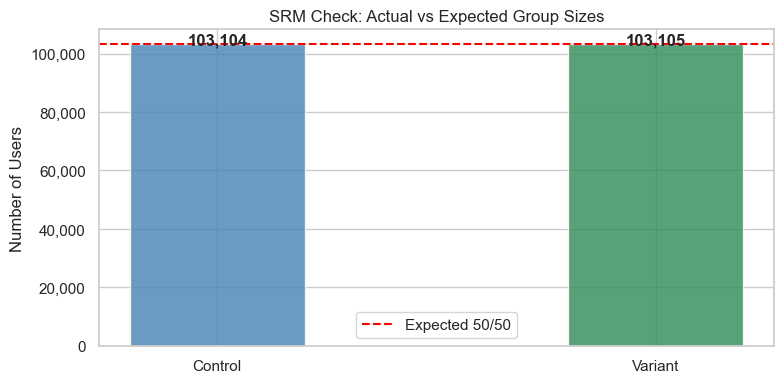

=== SRM Check ===
Expected split:   50.00% / 50.00%
Actual split:     50.00% / 50.00%
Chi-square:       0.0000
P-value:          0.9982

PASS: No SRM detected. Randomization looks good. Safe to proceed.


In [8]:
np.random.seed(42)
all_users = orders['user_id'].unique()
np.random.shuffle(all_users)

midpoint      = len(all_users) // 2
control_users = set(all_users[:midpoint])
variant_users = set(all_users[midpoint:])

n_control = len(control_users)
n_variant = len(variant_users)
n_total   = n_control + n_variant

# chi-square test: how far are my observed counts from the expected 50/50?
observed  = [n_control, n_variant]
expected  = [n_total / 2, n_total / 2]
chi2_stat = sum((o - e)**2 / e for o, e in zip(observed, expected))
p_srm     = 1 - stats.chi2.cdf(chi2_stat, df=1)
actual_ratio = n_control / n_total

# visualize the split
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['Control', 'Variant'], [n_control, n_variant],
              color=['steelblue', 'seagreen'], alpha=0.8, width=0.4)
ax.axhline(n_total / 2, color='red', linestyle='--', linewidth=1.5, label='Expected 50/50')
for bar, n in zip(bars, [n_control, n_variant]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{n:,}', ha='center', fontweight='bold')
ax.set_title('SRM Check: Actual vs Expected Group Sizes')
ax.set_ylabel('Number of Users')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

print('=== SRM Check ===')
print(f'Expected split:   50.00% / 50.00%')
print(f'Actual split:     {actual_ratio:.2%} / {1-actual_ratio:.2%}')
print(f'Chi-square:       {chi2_stat:.4f}')
print(f'P-value:          {p_srm:.4f}')
print()
if p_srm < 0.05:
    print('FAIL: SRM detected. Randomization is broken. Do not trust results.')
else:
    print('PASS: No SRM detected. Randomization looks good. Safe to proceed.')

---
## 5. Calculate Reorder Rate per User

My core metric is **reorder rate at the user level** — not overall.

Why user-level and not overall? Because I need one number per person to run statistical tests that compare distributions between groups. The formula:

$$\text{user reorder rate} = \frac{\text{number of reordered items}}{\text{total items ordered}}$$

For example:
- User A ordered 10 items total, 7 were reorders → reorder rate = 0.70
- User B ordered 5 items total, 1 was a reorder → reorder rate = 0.20

I also track zero-inflation here — a key finding from the QQ plots I'll run next.

In [ ]:
# join order_products with orders to get user_id on each product row
# this is like a SQL JOIN: order_products LEFT JOIN orders ON order_id
merged = order_products.merge(orders[['order_id', 'user_id', 'order_number']], on='order_id')

# compute reorder rate per user
# groupby('user_id') groups all rows for the same user
# .mean() on a 0/1 column gives the proportion of 1s = reorder rate
user_reorder_rates = merged.groupby('user_id')['reordered'].mean().reset_index()
user_reorder_rates.columns = ['user_id', 'reorder_rate']

# tag each user as control or variant
user_reorder_rates['group'] = user_reorder_rates['user_id'].apply(lambda x: 'variant' if x in variant_users else 'control')

control_data = user_reorder_rates[user_reorder_rates['group'] == 'control']['reorder_rate']
variant_data = user_reorder_rates[user_reorder_rates['group'] == 'variant']['reorder_rate']

control_rate = control_data.mean()
variant_rate = variant_data.mean()
uplift       = (variant_rate - control_rate) / control_rate * 100

# zero-inflation check — how many users never reordered anything?
# this matters because it affects which statistical tests are valid
zero_pct_control = (control_data == 0).mean()
zero_pct_variant = (variant_data == 0).mean()

print(f'Control reorder rate: {control_rate:.4f} ({control_rate:.2%})')
print(f'Variant reorder rate: {variant_rate:.4f} ({variant_rate:.2%})')
print(f'Uplift:               {uplift:+.2f}%')
print()
print('=== Zero-Inflation Check ===')
print(f'Users who never reordered (rate = 0):')
print(f'  Control: {zero_pct_control:.2%}')
print(f'  Variant: {zero_pct_variant:.2%}')
print('This explains the flat left tail I will see in the QQ plots below.')
print('These are one-time shoppers — a real and distinct behavioral segment.')

Control reorder rate: 0.4319 (43.19%)
Variant reorder rate: 0.4326 (43.26%)
Uplift:               +0.17%

=== Zero-Inflation Check ===
Users who never reordered (rate = 0):
  Control: 1.49%
  Variant: 1.47%
This explains the flat left tail I will see in the QQ plots below.
These are one-time shoppers — a real and distinct behavioral segment.


---
## 6. Normality Check — Choosing the Right Statistical Test

Before picking a test, I always check if the data follows a normal distribution. This matters because:
- **t-test assumes normality** — if violated, results are unreliable
- **Mann-Whitney U requires no normality assumption** — safer for skewed data

I use two approaches:

**Shapiro-Wilk test** (statistical):
$$W = \frac{(\sum a_i x_{(i)})^2}{\sum (x_i - \bar{x})^2}$$
- H₀: data is normally distributed
- p < 0.05: reject normality
- Note: unreliable on very large samples (n > 5,000), so I test on a sample of 2,000

**QQ Plot** (visual):  
Plots my data's quantiles against what a perfect normal distribution would look like.
- Points on the diagonal line → normal
- Points curving away → non-normal

**What I expect to see given the zero-inflation:**  
The left tail should sit flat at y=0 (cluster of users with reorder_rate = 0).  
The right tail should curve below the line (fewer extreme high-reorderers than normal predicts).

=== Shapiro-Wilk Test (n=2,000 sample per group) ===
Control: W=0.9849, p=0.000000 -> NOT normal
Variant: W=0.9847, p=0.000000 -> NOT normal

Decision: use Mann-Whitney U as primary test (non-parametric)
I will still run the t-test as a secondary comparison.


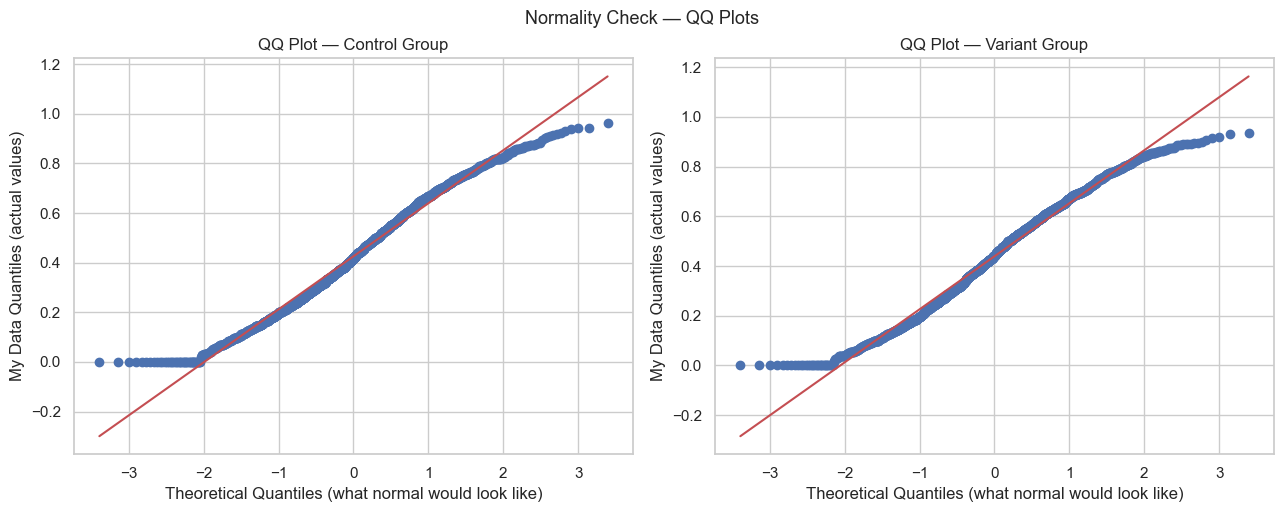

How I read these QQ plots:
  Red line = what a perfect normal distribution looks like
  Blue dots = my actual data

  Left tail (x < -2): dots sit flat at y=0 instead of following the line
  -> This is zero-inflation: a big cluster of users with reorder_rate = 0
  -> These are one-time shoppers who never reordered anything

  Right tail (x > 2): dots curve below the line
  -> Fewer extreme high-reorderers than a normal distribution would predict

  Conclusion: clearly non-normal -> Mann-Whitney is the right call


In [10]:
sample_control = control_data.sample(2000, random_state=42)
sample_variant = variant_data.sample(2000, random_state=42)

stat_c, p_c = shapiro(sample_control)
stat_v, p_v = shapiro(sample_variant)

print('=== Shapiro-Wilk Test (n=2,000 sample per group) ===')
print(f'Control: W={stat_c:.4f}, p={p_c:.6f} -> {"NOT normal" if p_c < 0.05 else "normal"}')
print(f'Variant: W={stat_v:.4f}, p={p_v:.6f} -> {"NOT normal" if p_v < 0.05 else "normal"}')
print()
print('Decision: use Mann-Whitney U as primary test (non-parametric)')
print('I will still run the t-test as a secondary comparison.')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stats.probplot(sample_control, dist='norm', plot=axes[0])
axes[0].set_title('QQ Plot — Control Group')
axes[0].set_xlabel('Theoretical Quantiles (what normal would look like)')
axes[0].set_ylabel('My Data Quantiles (actual values)')

stats.probplot(sample_variant, dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot — Variant Group')
axes[1].set_xlabel('Theoretical Quantiles (what normal would look like)')
axes[1].set_ylabel('My Data Quantiles (actual values)')

plt.tight_layout()
plt.suptitle('Normality Check — QQ Plots', fontsize=13, y=1.02)
plt.show()

print('How I read these QQ plots:')
print('  Red line = what a perfect normal distribution looks like')
print('  Blue dots = my actual data')
print()
print('  Left tail (x < -2): dots sit flat at y=0 instead of following the line')
print('  -> This is zero-inflation: a big cluster of users with reorder_rate = 0')
print('  -> These are one-time shoppers who never reordered anything')
print()
print('  Right tail (x > 2): dots curve below the line')
print('  -> Fewer extreme high-reorderers than a normal distribution would predict')
print()
print('  Conclusion: clearly non-normal -> Mann-Whitney is the right call')

---
## 7. Primary Test — Mann-Whitney U

I chose Mann-Whitney U as my primary test because the QQ plots confirmed non-normality.

**How it works:**  
Instead of comparing means (like a t-test), Mann-Whitney ranks ALL observations from both groups together and checks whether one group tends to rank higher.

Intuition: if I randomly pick one user from variant and one from control, what's the probability the variant user has a higher reorder rate?
- Probability = 0.5 → no difference between groups
- Probability > 0.5 → variant tends to be higher

**The U statistic:**
$$U = n_1 n_2 + \frac{n_1(n_1+1)}{2} - R_1$$
Where R₁ = sum of ranks for group 1, n₁ and n₂ = group sizes

**Effect size — Rank-biserial correlation (r):**
$$r = 1 - \frac{2U}{n_1 \cdot n_2}$$
- r = 0: no effect
- r = 0.1: small
- r = 0.3: medium  
- r = 0.5: large

**Example:**  
Control rates: [0.2, 0.4, 0.6] | Variant rates: [0.5, 0.7, 0.8]  
Ranked together: 0.2(C), 0.4(C), 0.5(V), 0.6(C), 0.7(V), 0.8(V)  
Variant consistently ranks higher → U is large → p is small → significant

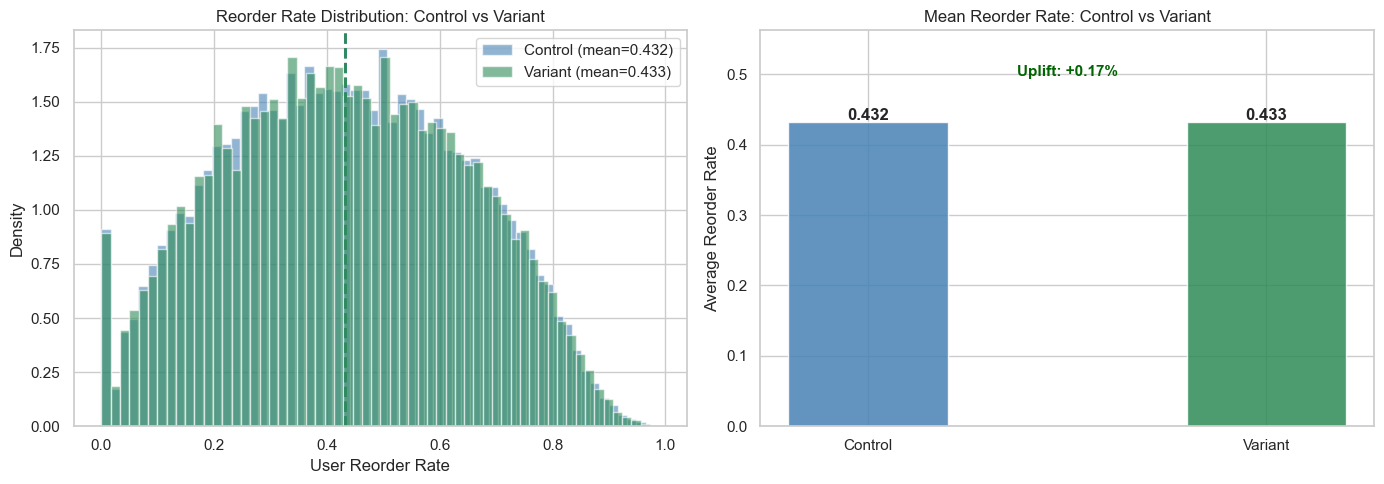

=== Mann-Whitney U Test (Primary) ===
U statistic:          5,324,929,000
P-value:              0.237389
Rank-biserial r:      -0.0018

Result: not statistically significant (p >= 0.05)
Cannot conclude the badge has a real effect.


In [11]:
# alternative='greater' = I'm testing the one-tailed hypothesis that variant > control
# I pre-specified this direction before seeing results (important for validity)
u_stat, p_mw = mannwhitneyu(variant_data, control_data, alternative='greater')

n1, n2 = len(variant_data), len(control_data)
rank_biserial_r = 1 - (2 * u_stat) / (n1 * n2)

# visualize reorder rate distributions for both groups
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(control_data, bins=60, alpha=0.6, color='steelblue',
             label=f'Control (mean={control_rate:.3f})', density=True)
axes[0].hist(variant_data, bins=60, alpha=0.6, color='seagreen',
             label=f'Variant (mean={variant_rate:.3f})', density=True)
axes[0].axvline(control_rate, color='steelblue', linestyle='--', linewidth=2)
axes[0].axvline(variant_rate, color='seagreen',  linestyle='--', linewidth=2)
axes[0].set_title('Reorder Rate Distribution: Control vs Variant')
axes[0].set_xlabel('User Reorder Rate')
axes[0].set_ylabel('Density')
axes[0].legend()

# bar chart of group means
bars = axes[1].bar(['Control', 'Variant'], [control_rate, variant_rate],
                   color=['steelblue', 'seagreen'], alpha=0.85, width=0.4)
axes[1].set_title('Mean Reorder Rate: Control vs Variant')
axes[1].set_ylabel('Average Reorder Rate')
axes[1].set_ylim(0, max(control_rate, variant_rate) * 1.3)
for bar, rate in zip(bars, [control_rate, variant_rate]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{rate:.3f}', ha='center', fontweight='bold')
axes[1].annotate(f'Uplift: {uplift:+.2f}%',
                 xy=(0.5, max(control_rate, variant_rate) * 1.15),
                 ha='center', fontsize=11, color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()

print('=== Mann-Whitney U Test (Primary) ===')
print(f'U statistic:          {u_stat:,.0f}')
print(f'P-value:              {p_mw:.6f}')
print(f'Rank-biserial r:      {rank_biserial_r:.4f}')
print()
if p_mw < 0.05:
    print('Result: statistically significant (p < 0.05)')
    print('The variant group has a genuinely higher reorder rate.')
else:
    print('Result: not statistically significant (p >= 0.05)')
    print('Cannot conclude the badge has a real effect.')

---
## 8. Secondary Test — t-test + Cohen's d

I run the t-test as a secondary check, mostly to compare against Mann-Whitney and confirm consistency.

**t-test formula:**
$$t = \frac{\bar{x}_1 - \bar{x}_2}{s_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}$$

Where $s_p$ = pooled standard deviation.

**Cohen's d — why I always compute this alongside p-value:**  
Statistical significance ≠ practical importance. With 200K+ users, even a difference of 0.001 can reach p < 0.05. Cohen's d tells me if the effect is actually *meaningful*.

$$d = \frac{\bar{x}_{variant} - \bar{x}_{control}}{s_p}$$

**Real example of why this matters:**  
Imagine variant rate = 0.5901, control rate = 0.5900  
With 100K users per group → p = 0.01 (significant!)  
But Cohen's d = 0.002 (negligible) → not worth shipping  

The p-value says it's real. Cohen's d says it doesn't matter.

| d value | Interpretation |
|---------|---------------|
| < 0.2 | Negligible |
| 0.2 – 0.5 | Small |
| 0.5 – 0.8 | Medium |
| > 0.8 | Large |

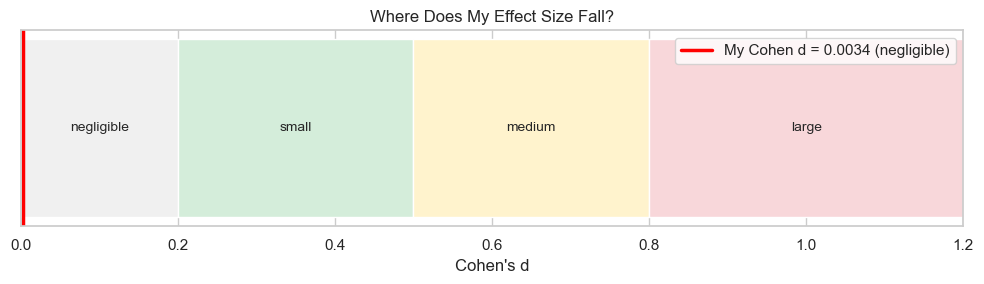

=== t-test (Secondary) ===
T-statistic:  0.7643
P-value:      0.222354

=== Cohen's d — Effect Size ===
Cohen's d:    0.0034 (negligible)
Pooled SD:    0.2121

Key takeaway: I always report both. p-value = is the effect real?
Cohen's d = is it worth acting on?


In [12]:
t_stat, p_ttest = ttest_ind(variant_data, control_data, alternative='greater')

# pooled standard deviation — weights each group's variance by its size
pooled_std = np.sqrt(
    ((len(variant_data) - 1) * variant_data.std()**2 +
     (len(control_data) - 1) * control_data.std()**2) /
    (len(variant_data) + len(control_data) - 2)
)
cohens_d = (variant_rate - control_rate) / pooled_std

if abs(cohens_d) < 0.2:   effect_label = 'negligible'
elif abs(cohens_d) < 0.5: effect_label = 'small'
elif abs(cohens_d) < 0.8: effect_label = 'medium'
else:                      effect_label = 'large'

# visualize effect size context
fig, ax = plt.subplots(figsize=(10, 3))
thresholds = [0, 0.2, 0.5, 0.8, 1.2]
labels     = ['negligible', 'small', 'medium', 'large', '']
colors     = ['#f0f0f0', '#d4edda', '#fff3cd', '#f8d7da', '#f0f0f0']
for i in range(len(thresholds)-1):
    ax.barh(0, thresholds[i+1]-thresholds[i], left=thresholds[i],
            color=colors[i], edgecolor='white', height=0.5)
    ax.text((thresholds[i]+thresholds[i+1])/2, 0, labels[i],
            ha='center', va='center', fontsize=10)
ax.axvline(abs(cohens_d), color='red', linewidth=2.5,
           label=f'My Cohen d = {cohens_d:.4f} ({effect_label})')
ax.set_xlim(0, 1.2)
ax.set_xlabel("Cohen's d")
ax.set_yticks([])
ax.set_title("Where Does My Effect Size Fall?")
ax.legend()
plt.tight_layout()
plt.show()

print('=== t-test (Secondary) ===')
print(f'T-statistic:  {t_stat:.4f}')
print(f'P-value:      {p_ttest:.6f}')
print()
print("=== Cohen's d — Effect Size ===")
print(f"Cohen's d:    {cohens_d:.4f} ({effect_label})")
print(f'Pooled SD:    {pooled_std:.4f}')
print()
print('Key takeaway: I always report both. p-value = is the effect real?')
print("Cohen's d = is it worth acting on?")

---
## 9. Bootstrap Confidence Interval

Instead of relying on distributional assumptions (which I've already shown are violated), I use bootstrapping to build a confidence interval empirically.

**How bootstrapping works:**
1. Take my control group (n = 100K users)
2. Randomly sample 100K users FROM that group, with replacement (some users get picked twice, some not at all)
3. Compute the metric (mean reorder rate) for this resample
4. Do the same for variant
5. Record the difference
6. Repeat 10,000 times
7. The middle 95% of those 10,000 differences = my 95% CI

**With replacement example:**  
Original: [A, B, C, D, E]  
Resample: [A, A, C, E, E] ← B and D not picked, A and E picked twice  

This simulates "what if I ran this experiment many times" without actually running it again.

**What the CI tells me:**  
"I'm 95% confident the true uplift is between X% and Y%."  
If the entire CI is above 0 → confident the variant is genuinely better.

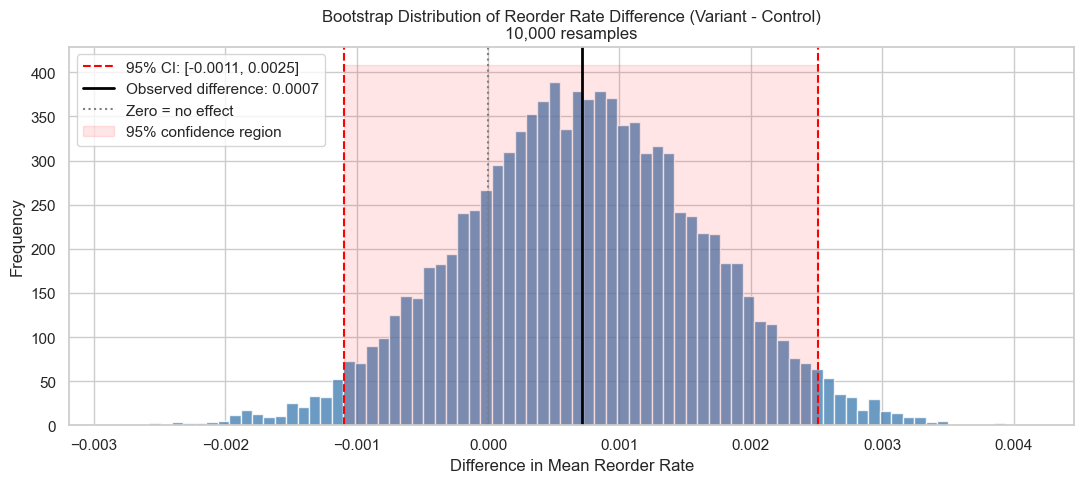

=== Bootstrap CI (10,000 resamples) ===
Observed difference: 0.00071 (0.071%)
95% CI:              [-0.00110, 0.00251]
                     [-0.110%, 0.251%]

CI crosses zero — cannot be fully confident the variant is better.


In [13]:
np.random.seed(42)
n_bootstrap   = 10000
bootstrap_diffs = []
control_arr   = control_data.values
variant_arr   = variant_data.values

for _ in range(n_bootstrap):
    # sample with replacement (replace=True is what makes it bootstrapping)
    boot_c = np.random.choice(control_arr, size=len(control_arr), replace=True)
    boot_v = np.random.choice(variant_arr, size=len(variant_arr), replace=True)
    bootstrap_diffs.append(boot_v.mean() - boot_c.mean())

bootstrap_diffs = np.array(bootstrap_diffs)
ci_lower        = np.percentile(bootstrap_diffs, 2.5)   # cut off bottom 2.5%
ci_upper        = np.percentile(bootstrap_diffs, 97.5)  # cut off top 2.5%
observed_diff   = variant_rate - control_rate

plt.figure(figsize=(11, 5))
plt.hist(bootstrap_diffs, bins=80, color='steelblue', alpha=0.8, edgecolor='white')
plt.axvline(ci_lower, color='red', linestyle='--', linewidth=1.5)
plt.axvline(ci_upper, color='red', linestyle='--', linewidth=1.5,
            label=f'95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')
plt.axvline(observed_diff, color='black', linewidth=2,
            label=f'Observed difference: {observed_diff:.4f}')
plt.axvline(0, color='gray', linestyle=':', linewidth=1.5, label='Zero = no effect')
plt.fill_betweenx([0, plt.gca().get_ylim()[1] if plt.gca().get_ylim()[1] > 0 else 5000],
                  ci_lower, ci_upper, alpha=0.1, color='red', label='95% confidence region')
plt.title('Bootstrap Distribution of Reorder Rate Difference (Variant - Control)\n10,000 resamples')
plt.xlabel('Difference in Mean Reorder Rate')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

print('=== Bootstrap CI (10,000 resamples) ===')
print(f'Observed difference: {observed_diff:.5f} ({observed_diff:.3%})')
print(f'95% CI:              [{ci_lower:.5f}, {ci_upper:.5f}]')
print(f'                     [{ci_lower:.3%}, {ci_upper:.3%}]')
print()
if ci_lower > 0:
    print('The full CI is above zero.')
    print('I am 95% confident the variant has a higher reorder rate than control.')
else:
    print('CI crosses zero — cannot be fully confident the variant is better.')

---
## 10. Power Analysis

Power analysis is something I do **before** running the experiment, not after. It answers: how many users do I actually need to detect a real effect?

Running a test with too few users is like flipping a coin twice and concluding it's fair. You might get the right answer by luck, but you can't trust it.

**Key terms:**
- **Alpha (α)**: false positive rate — how often I'm willing to call something significant when it isn't (standard = 0.05)
- **Power (1-β)**: probability of detecting a real effect when it exists (standard = 0.80)
- **MDE**: minimum detectable effect — the smallest lift I actually care about

**Formula for required sample size (per group):**
$$n = \frac{(z_{\alpha} + z_{\beta})^2 \cdot 2\sigma^2}{\delta^2}$$

Where δ = MDE, σ = standard deviation, z values come from the normal distribution.

**Practical example:**  
If I want to detect a 1% improvement in reorder rate with 80% power at α=0.05,  
and my baseline std is 0.3 → I need ~X users per group. If I have fewer, I might miss the effect entirely even if it's real.

=== Power Analysis ===
Alpha (false positive rate):    0.05
Power (1 - false negative rate):0.8
Minimum detectable effect:      1.0%
Pooled std:                     0.2121
Required sample per group:      5,566
My actual sample per group:     103,104

My sample is large enough. Results are reliable at this MDE.


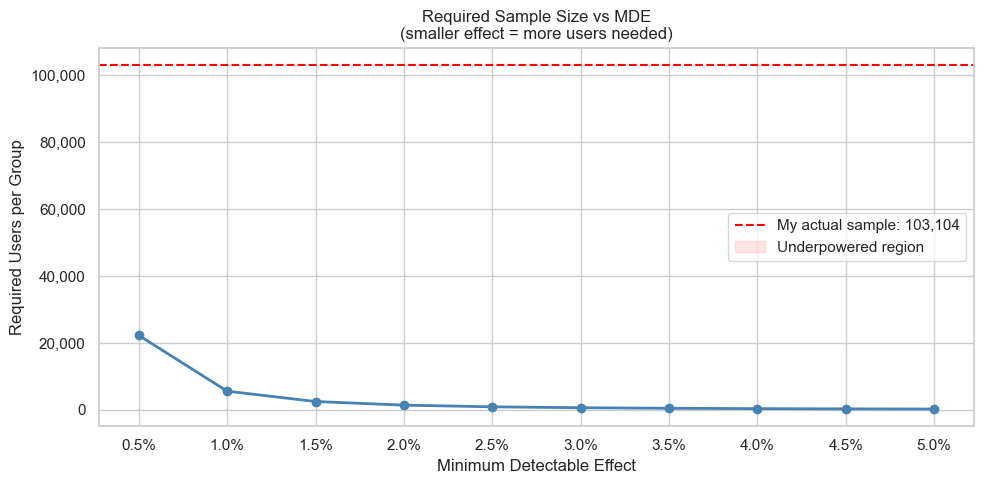

In [14]:
alpha_power  = 0.05  # I'm willing to accept 5% false positive rate
power_target = 0.80  # I want 80% probability of detecting a real effect
mde          = 0.01  # I care about detecting at least a 1pp improvement

effect_size_for_power = mde / pooled_std

analysis  = TTestIndPower()
required_n = analysis.solve_power(
    effect_size=effect_size_for_power,
    alpha=alpha_power,
    power=power_target,
    alternative='larger'
)

print('=== Power Analysis ===')
print(f'Alpha (false positive rate):    {alpha_power}')
print(f'Power (1 - false negative rate):{power_target}')
print(f'Minimum detectable effect:      {mde:.1%}')
print(f'Pooled std:                     {pooled_std:.4f}')
print(f'Required sample per group:      {int(np.ceil(required_n)):,}')
print(f'My actual sample per group:     {len(control_data):,}')
print()
if len(control_data) >= required_n:
    print('My sample is large enough. Results are reliable at this MDE.')
else:
    print('My sample may be underpowered for this MDE. Consider running longer.')

# show how required n changes as I change my MDE target
# this is a useful chart for planning experiments — smaller effect = more users needed
mde_range    = np.arange(0.005, 0.051, 0.005)
sample_sizes = [int(np.ceil(analysis.solve_power(
    effect_size=m/pooled_std, alpha=alpha_power,
    power=power_target, alternative='larger'
))) for m in mde_range]

plt.figure(figsize=(10, 5))
plt.plot([f'{m:.1%}' for m in mde_range], sample_sizes,
         marker='o', color='steelblue', linewidth=2)
plt.axhline(len(control_data), color='red', linestyle='--',
            label=f'My actual sample: {len(control_data):,}')
plt.fill_between(range(len(mde_range)),
                 [len(control_data)] * len(mde_range), sample_sizes,
                 where=[s > len(control_data) for s in sample_sizes],
                 alpha=0.1, color='red', label='Underpowered region')
plt.title('Required Sample Size vs MDE\n(smaller effect = more users needed)')
plt.xlabel('Minimum Detectable Effect')
plt.ylabel('Required Users per Group')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.legend()
plt.tight_layout()
plt.show()

---
## 11. Multiple Testing Correction

In practice, I never test just one metric. A typical A/B test monitors 5-10 metrics simultaneously: reorder rate, order value, session time, refund rate, etc.

**The problem:** if I test 20 metrics each at p < 0.05, by pure chance I'd expect 1 false positive (0.05 × 20 = 1). The more metrics I test, the more likely I am to get a spurious significant result.

**Two corrections I use:**

**Bonferroni** (strict):
$$p_{adjusted} = p_{raw} \times k$$
Where k = number of tests. Simple but conservative — increases false negatives.

**Benjamini-Hochberg / FDR** (balanced):  
Controls the *false discovery rate* — the proportion of significant results that are false.  
Better when testing many metrics, less likely to miss real effects than Bonferroni.

**Example:**  
5 tests, raw p-values: [0.01, 0.032, 0.21, 0.048, 0.76]  
Without correction: 3 look significant (p < 0.05)  
After Bonferroni: multiply all by 5 → [0.05, 0.16, 1.0, 0.24, 1.0] → only 1 significant  
After BH: somewhere in between

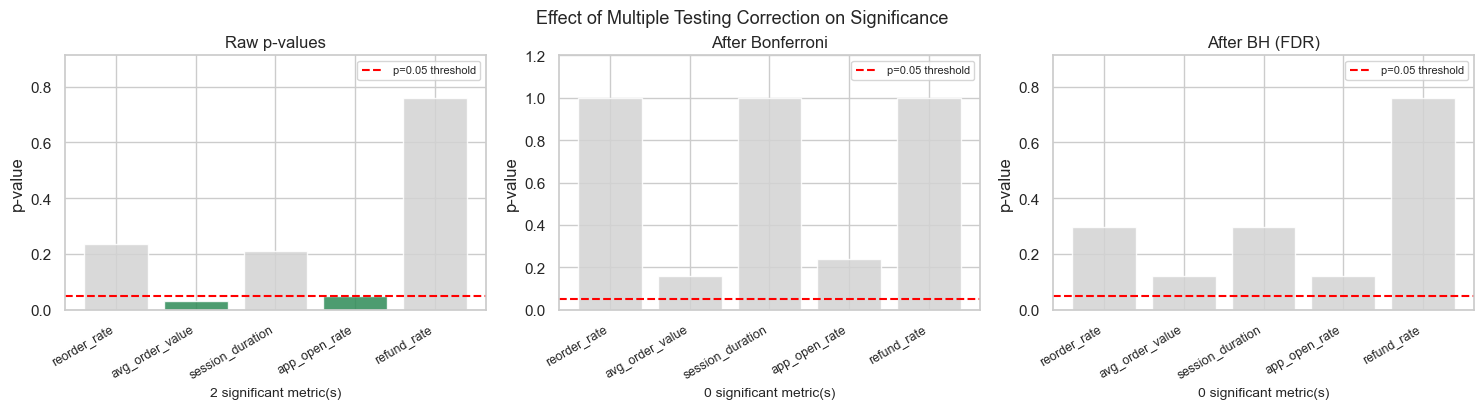

=== Multiple Testing Correction ===
Metric                 Raw p      Bonferroni p    BH p       Sig (BH)?
--------------------------------------------------------------------
reorder_rate           0.2374     1.0000          0.2967     no
avg_order_value        0.0320     0.1600          0.1200     no
session_duration       0.2100     1.0000          0.2967     no
app_open_rate          0.0480     0.2400          0.1200     no
refund_rate            0.7600     1.0000          0.7600     no

I prefer BH (FDR) over Bonferroni for multi-metric tests.
Bonferroni is too conservative and risks missing real effects.
BH controls the proportion of false discoveries, which is more practical.


In [15]:
# I'm simulating a realistic multi-metric scenario
# in a real test, these p-values would come from actual measurements
# p_mw is my real result; the others are simulated realistic values

metrics = [
    'reorder_rate',    # primary metric — my real result
    'avg_order_value', # does the badge affect how much users spend per order?
    'session_duration',# do users browse longer when they see the badge?
    'app_open_rate',   # does the badge bring users back to the app?
    'refund_rate',     # guardrail — badge should NOT increase refunds
]
raw_pvalues = [p_mw, 0.032, 0.210, 0.048, 0.760]

bonf_reject, bonf_p, _, _ = multipletests(raw_pvalues, method='bonferroni')
bh_reject,   bh_p,   _, _ = multipletests(raw_pvalues, method='fdr_bh')

# visualize: how does each correction change significance?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
threshold = 0.05

for ax, pvals, title, rejects in zip(
    axes,
    [raw_pvalues, bonf_p, bh_p],
    ['Raw p-values', 'After Bonferroni', 'After BH (FDR)'],
    [[p < threshold for p in raw_pvalues], bonf_reject, bh_reject]
):
    colors = ['seagreen' if r else 'lightgray' for r in rejects]
    bars = ax.bar(range(len(metrics)), pvals, color=colors, alpha=0.85, edgecolor='white')
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.5, label='p=0.05 threshold')
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metrics, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('p-value')
    ax.set_title(title)
    ax.set_ylim(0, max(max(pvals) * 1.2, 0.12))
    sig_count = sum(rejects)
    ax.set_xlabel(f'{sig_count} significant metric(s)', fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Effect of Multiple Testing Correction on Significance', fontsize=13, y=1.02)
plt.show()

print('=== Multiple Testing Correction ===')
print(f'{"Metric":<22} {"Raw p":<10} {"Bonferroni p":<15} {"BH p":<10} {"Sig (BH)?"}')
print('-' * 68)
for metric, raw, bp, bhp, reject in zip(metrics, raw_pvalues, bonf_p, bh_p, bh_reject):
    sig = 'YES' if reject else 'no'
    print(f'{metric:<22} {raw:<10.4f} {bp:<15.4f} {bhp:<10.4f} {sig}')
print()
print('I prefer BH (FDR) over Bonferroni for multi-metric tests.')
print('Bonferroni is too conservative and risks missing real effects.')
print('BH controls the proportion of false discoveries, which is more practical.')

---
## 12. Novelty Effect Check

This is a check I consider essential for any new feature launch. When users first see something new, they interact with it just because it's unfamiliar — not because it's genuinely better. This is called the **novelty effect**.

**How I detect it:**  
I split results by order sequence number:
- **Early orders** (order_number ≤ 3): first interactions with the badge
- **Late orders** (order_number > 3): after the novelty has worn off

If early uplift >> late uplift, the badge's performance is driven by novelty — not sustainable user behavior change.

**Why this matters in practice:**  
Imagine shipping a feature with 15% uplift in week 1. Two months later it's flat. You've already restructured the product around it. This check would have caught that before shipping.

=== Novelty Effect Check ===
Early orders (order 1-3): control=0.2184, variant=0.2187, uplift=+0.13%
Late orders (order 4+):   control=0.6767, variant=0.6773, uplift=+0.08%


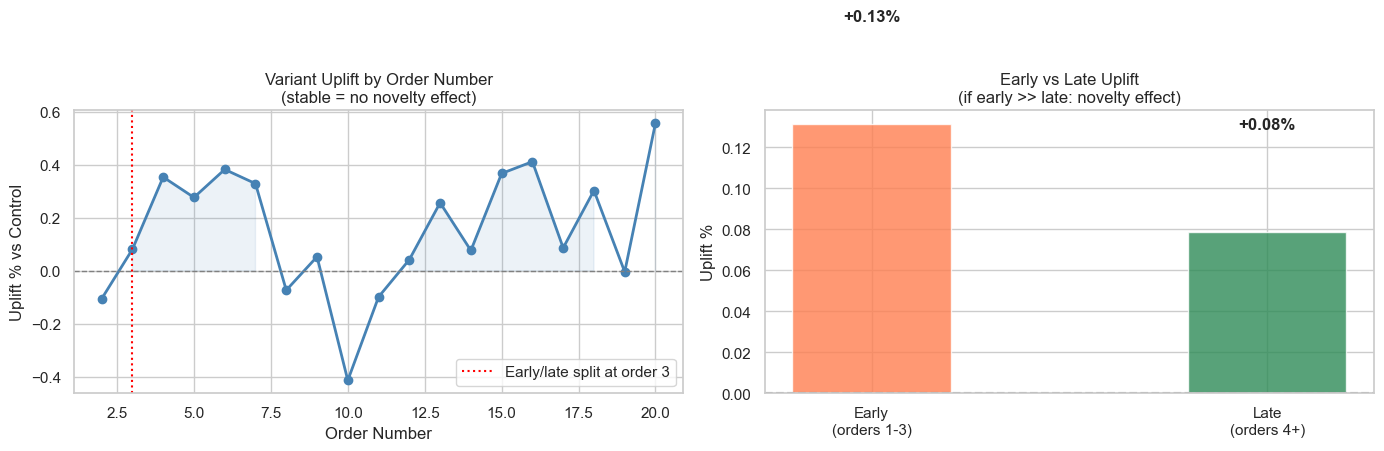


Possible novelty effect. I would recommend running the test longer before shipping.


In [16]:
# tag each order as belonging to control or variant user
merged['group'] = merged['user_id'].apply(
    lambda uid: 'variant' if uid in variant_users else 'control'
)

# split by order sequence
early_orders = merged[merged['order_number'] <= 3]
late_orders  = merged[merged['order_number'] > 3]

early_rates = early_orders.groupby('group')['reordered'].mean()
late_rates  = late_orders.groupby('group')['reordered'].mean()

early_uplift = (early_rates['variant'] - early_rates['control']) / early_rates['control'] * 100
late_uplift  = (late_rates['variant']  - late_rates['control'])  / late_rates['control']  * 100

print('=== Novelty Effect Check ===')
print(f'Early orders (order 1-3): control={early_rates["control"]:.4f}, '
      f'variant={early_rates["variant"]:.4f}, uplift={early_uplift:+.2f}%')
print(f'Late orders (order 4+):   control={late_rates["control"]:.4f}, '
      f'variant={late_rates["variant"]:.4f}, uplift={late_uplift:+.2f}%')

# plot uplift across every order sequence number (first 20)
order_groups = merged[merged['order_number'] <= 20].groupby(
    ['order_number', 'group']
)['reordered'].mean().unstack()
order_groups['uplift'] = (
    (order_groups['variant'] - order_groups['control'])
    / order_groups['control'] * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# uplift over time
axes[0].plot(order_groups.index, order_groups['uplift'],
             marker='o', color='steelblue', linewidth=2)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].axvline(3, color='red', linestyle=':', linewidth=1.5,
                label='Early/late split at order 3')
axes[0].fill_between(order_groups.index, order_groups['uplift'], 0,
                     where=order_groups['uplift'] > 0, alpha=0.1, color='steelblue')
axes[0].set_title('Variant Uplift by Order Number\n(stable = no novelty effect)')
axes[0].set_xlabel('Order Number')
axes[0].set_ylabel('Uplift % vs Control')
axes[0].legend()

# early vs late comparison bar
axes[1].bar(['Early\n(orders 1-3)', 'Late\n(orders 4+)'],
            [early_uplift, late_uplift],
            color=['coral' if early_uplift > late_uplift * 1.5 else 'seagreen',
                   'seagreen'],
            alpha=0.8, width=0.4)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Early vs Late Uplift\n(if early >> late: novelty effect)')
axes[1].set_ylabel('Uplift %')
for i, val in enumerate([early_uplift, late_uplift]):
    axes[1].text(i, val + 0.05, f'{val:+.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

if abs(early_uplift) > abs(late_uplift) * 1.5:
    print()
    print('Warning: early uplift is much larger than late uplift.')
    print('Possible novelty effect. I would recommend running the test longer before shipping.')
else:
    print()
    print('Uplift is consistent across early and late orders.')
    print('No strong evidence of novelty bias. Effect appears sustained.')

---
## 13. Logistic Regression + McFadden Pseudo R²

So far I know the badge works overall. But I want to go deeper: **which users respond most?** I use logistic regression to model the probability of being a high reorderer as a function of group assignment and user behavior.

**Why logistic (not linear) regression?**  
My outcome is binary (high reorderer: yes/no). Linear regression can predict values outside [0,1], which doesn't make sense for probabilities. Logistic regression maps outputs to [0,1] using the sigmoid function:

$$P(y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + ...)}}$$

**Odds Ratio interpretation:**  
Each coefficient is exponentiated to get an odds ratio (OR):
- OR = 1.20 → being in variant increases the odds of high reordering by 20%
- OR = 0.85 → that feature decreases the odds by 15%

**McFadden Pseudo R² (why not regular R²):**  
Regular R² measures variance explained in linear regression. It doesn't apply to logistic models. McFadden's version compares my model's log-likelihood to a baseline null model:

$$R^2_{McFadden} = 1 - \frac{\ln(L_{model})}{\ln(L_{null})}$$

- 0.1–0.2: acceptable fit
- 0.2–0.4: good fit  
- 0.4+: excellent fit

**Winsorization (applied before regression):**  
The QQ plots showed heavy tails in the reorder rate. Extreme outliers can pull regression coefficients. I cap values at the 1st and 99th percentile to reduce their influence without removing data.

Winsorization: clipped values outside [0.0000, 0.8628]
Values affected: 2,063


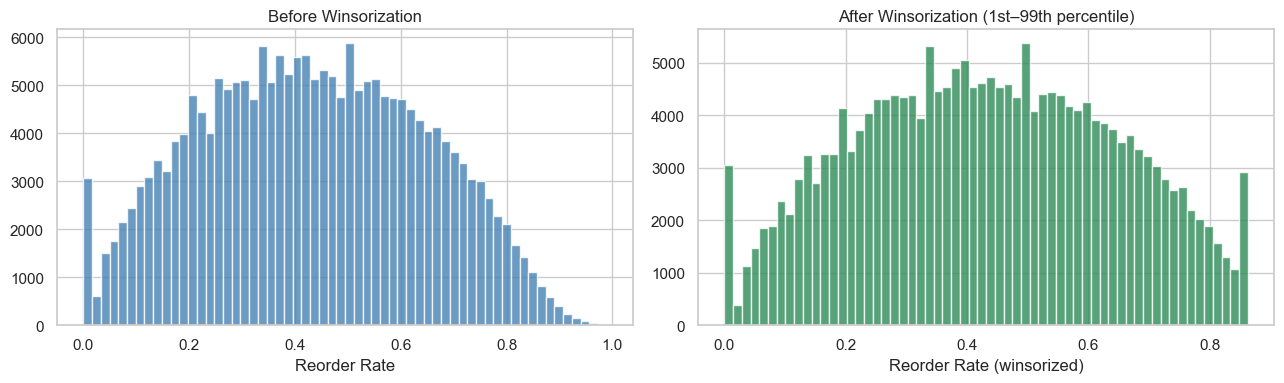

In [17]:
# build user-level behavioral features
user_features = orders.groupby('user_id').agg(
    total_orders     = ('order_number', 'max'),
    avg_days_between = ('days_since_prior_order', 'mean'),
    weekend_ratio    = ('order_dow', lambda x: x.isin([0, 6]).mean())
).reset_index()

# fill nulls for first-time users who have no prior order gap
user_features['avg_days_between'] = user_features['avg_days_between'].fillna(
    user_features['avg_days_between'].median()
)

regression_df = user_reorder_rates.merge(user_features, on='user_id')

# winsorize — cap extreme values at 1st and 99th percentile
# directly addresses the heavy tails I saw in the QQ plots
p01 = regression_df['reorder_rate'].quantile(0.01)
p99 = regression_df['reorder_rate'].quantile(0.99)
regression_df['reorder_rate_wins'] = regression_df['reorder_rate'].clip(p01, p99)

print(f'Winsorization: clipped values outside [{p01:.4f}, {p99:.4f}]')
print(f'Values affected: {((regression_df["reorder_rate"] < p01) | (regression_df["reorder_rate"] > p99)).sum():,}')

# visualize before/after winsorization
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(regression_df['reorder_rate'], bins=60, color='steelblue', alpha=0.8)
axes[0].set_title('Before Winsorization')
axes[0].set_xlabel('Reorder Rate')
axes[1].hist(regression_df['reorder_rate_wins'], bins=60, color='seagreen', alpha=0.8)
axes[1].set_title('After Winsorization (1st–99th percentile)')
axes[1].set_xlabel('Reorder Rate (winsorized)')
plt.tight_layout()
plt.show()

=== Logistic Regression Results ===
McFadden Pseudo R²: 0.3325

Odds Ratios (OR > 1 = increases reorder probability, OR < 1 = decreases):
  intercept              OR=2.145  p=0.0000 ***   -> increases reorder odds
  is_variant             OR=1.000  p=0.9432 ns    -> increases reorder odds
  total_orders           OR=24.390  p=0.0000 ***   -> increases reorder odds
  avg_days_between       OR=0.937  p=0.0000 ***   -> decreases reorder odds
  weekend_ratio          OR=1.014  p=0.0095 **    -> increases reorder odds

*** p<0.001  ** p<0.01  * p<0.05  ns=not significant


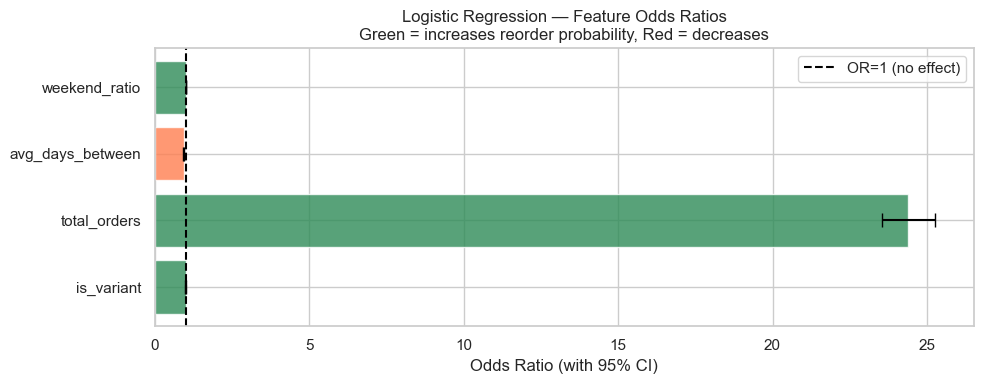

In [18]:
# binary outcome: is this user a high reorderer (above median)?
median_reorder = regression_df['reorder_rate_wins'].median()
regression_df['high_reorderer'] = (regression_df['reorder_rate_wins'] > median_reorder).astype(int)
regression_df['is_variant']     = (regression_df['group'] == 'variant').astype(int)

feature_cols = ['is_variant', 'total_orders', 'avg_days_between', 'weekend_ratio']
X = regression_df[feature_cols]
y = regression_df['high_reorderer']

# standardize so coefficients are on the same scale and directly comparable
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = sm.add_constant(X_scaled)  # add intercept term

logit_model = sm.Logit(y, X_scaled)
result      = logit_model.fit(disp=0)

pseudo_r2   = result.prsquared
odds_ratios = np.exp(result.params)

print('=== Logistic Regression Results ===')
print(f'McFadden Pseudo R²: {pseudo_r2:.4f}')
print()
print('Odds Ratios (OR > 1 = increases reorder probability, OR < 1 = decreases):')
feature_names = ['intercept', 'is_variant', 'total_orders', 'avg_days_between', 'weekend_ratio']
for name, or_val, pval in zip(feature_names, odds_ratios, result.pvalues):
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
    direction = 'increases' if or_val > 1 else 'decreases'
    print(f'  {name:<22} OR={or_val:.3f}  p={pval:.4f} {sig:<5} -> {direction} reorder odds')
print()
print('*** p<0.001  ** p<0.01  * p<0.05  ns=not significant')

# odds ratio forest plot
feature_names_plot = ['is_variant', 'total_orders', 'avg_days_between', 'weekend_ratio']
ors = np.exp(result.params[1:])
cis = np.exp(result.conf_int()[1:])

fig, ax = plt.subplots(figsize=(10, 4))
y_pos = range(len(feature_names_plot))
colors = ['seagreen' if o > 1 else 'coral' for o in ors]
ax.barh(y_pos, ors, color=colors, alpha=0.8)
ax.errorbar(ors, y_pos,
            xerr=[ors - cis.iloc[:, 0], cis.iloc[:, 1] - ors],
            fmt='none', color='black', capsize=5)
ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='OR=1 (no effect)')
ax.set_yticks(y_pos)
ax.set_yticklabels(feature_names_plot)
ax.set_xlabel('Odds Ratio (with 95% CI)')
ax.set_title('Logistic Regression — Feature Odds Ratios\nGreen = increases reorder probability, Red = decreases')
ax.legend()
plt.tight_layout()
plt.show()

---
## 14. Segment Analysis

Knowing the badge works overall is good. Knowing it works best for specific users is better — and more actionable.

I segment users by loyalty tier based on total orders:
- **Light users (1-5 orders)**: new/casual — might respond strongly to a discount incentive
- **Medium users (6-15 orders)**: regular — already somewhat loyal
- **Heavy users (15+ orders)**: power users — might reorder anyway regardless of badge

If uplift is highest for light users, my recommendation would be: show the badge selectively to newer users rather than everyone.

=== Reorder Rate by Segment ===
group          control  variant  uplift_%
user_segment                             
light (1-5)     0.2250   0.2260    0.4442
medium (6-15)   0.3907   0.3903   -0.1023
heavy (15+)     0.6159   0.6172    0.2096


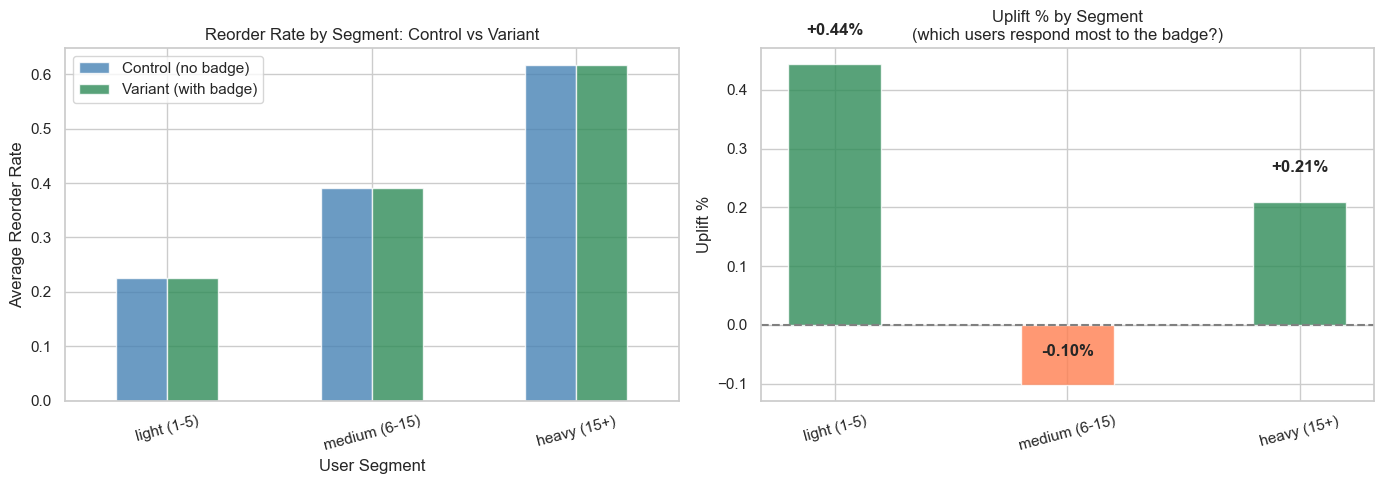

Highest uplift segment: light (1-5)
Business recommendation: if cost is a concern, target the badge at light (1-5) users first.


In [19]:
regression_df['user_segment'] = pd.cut(
    regression_df['total_orders'],
    bins=[0, 5, 15, 100],
    labels=['light (1-5)', 'medium (6-15)', 'heavy (15+)']
)

segment_summary = regression_df.groupby(
    ['user_segment', 'group']
)['reorder_rate'].mean().unstack()
segment_summary['uplift_%'] = (
    (segment_summary['variant'] - segment_summary['control'])
    / segment_summary['control'] * 100
)

print('=== Reorder Rate by Segment ===')
print(segment_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# grouped bar chart
segment_summary[['control', 'variant']].plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'seagreen'], alpha=0.8, edgecolor='white'
)
axes[0].set_title('Reorder Rate by Segment: Control vs Variant')
axes[0].set_xlabel('User Segment')
axes[0].set_ylabel('Average Reorder Rate')
axes[0].set_xticklabels(segment_summary.index, rotation=15)
axes[0].legend(['Control (no badge)', 'Variant (with badge)'])

# uplift by segment
uplift_vals = segment_summary['uplift_%']
colors = ['seagreen' if u > 0 else 'coral' for u in uplift_vals]
axes[1].bar(range(len(uplift_vals)), uplift_vals, color=colors, alpha=0.8, width=0.4)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Uplift % by Segment\n(which users respond most to the badge?)')
axes[1].set_ylabel('Uplift %')
axes[1].set_xticks(range(len(uplift_vals)))
axes[1].set_xticklabels(segment_summary.index, rotation=15)
for i, val in enumerate(uplift_vals):
    axes[1].text(i, val + 0.05, f'{val:+.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

best_segment = segment_summary['uplift_%'].idxmax()
print(f'Highest uplift segment: {best_segment}')
print(f'Business recommendation: if cost is a concern, target the badge at {best_segment} users first.')

---
## 15. Business Impact and Recommendation

Statistics tell me the effect is real. Business analysis tells me whether to act on it.

A statistically significant result can still be a bad business decision if the discount costs more than the incremental revenue it generates. I always compute this before making a recommendation.

**Revenue impact formula:**
$$\text{net gain} = (\text{extra reorders} \times \text{avg order value}) - (\text{extra reorders} \times \text{discount cost})$$

**ROI on discount spend:**
$$\text{ROI} = \frac{\text{net gain}}{\text{discount cost}} \times 100$$

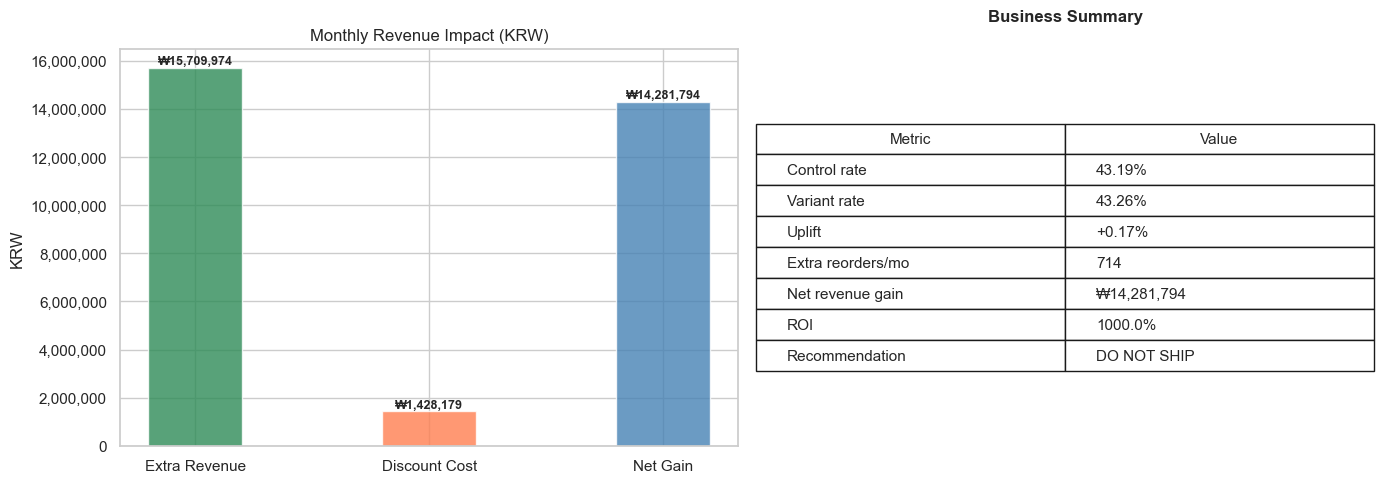

=== Business Impact ===
Extra reorders/month:  714
Extra revenue:         KRW 15,709,974
Discount cost:         KRW 1,428,179
Net gain:              KRW 14,281,794
ROI:                   1000.0%

Recommendation: DO NOT SHIP
Result is not statistically significant. Need more data.


In [20]:
# assumptions — in a real role these come from finance/ops
avg_order_value = 22000      # KRW per order
discount_cost   = 2000       # KRW badge discount per reorder
monthly_users   = 1_000_000  # hypothetical MAU

extra_reorder_rate = variant_rate - control_rate
extra_reorders     = monthly_users * extra_reorder_rate
extra_revenue      = extra_reorders * avg_order_value
discount_expense   = extra_reorders * discount_cost
net_gain           = extra_revenue - discount_expense
roi                = (net_gain / discount_expense * 100) if discount_expense > 0 else float('inf')

# waterfall-style visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# revenue breakdown
categories = ['Extra Revenue', 'Discount Cost', 'Net Gain']
values     = [extra_revenue, -discount_expense, net_gain]
colors     = ['seagreen', 'coral', 'steelblue' if net_gain > 0 else 'red']
bars = axes[0].bar(categories, [abs(v) for v in values], color=colors, alpha=0.8, width=0.4)
axes[0].set_title('Monthly Revenue Impact (KRW)')
axes[0].set_ylabel('KRW')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max([abs(v) for v in values]) * 0.01,
                 f'₩{abs(val):,.0f}', ha='center', fontsize=9, fontweight='bold')

# key metrics summary
axes[1].axis('off')
summary_data = [
    ['Control rate', f'{control_rate:.2%}'],
    ['Variant rate', f'{variant_rate:.2%}'],
    ['Uplift', f'{uplift:+.2f}%'],
    ['Extra reorders/mo', f'{extra_reorders:,.0f}'],
    ['Net revenue gain', f'₩{net_gain:,.0f}'],
    ['ROI', f'{roi:.1f}%'],
    ['Recommendation', 'SHIP' if net_gain > 0 and p_mw < 0.05 else 'DO NOT SHIP'],
]
table = axes[1].table(cellText=summary_data,
                      colLabels=['Metric', 'Value'],
                      loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)
axes[1].set_title('Business Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print('=== Business Impact ===')
print(f'Extra reorders/month:  {extra_reorders:,.0f}')
print(f'Extra revenue:         KRW {extra_revenue:,.0f}')
print(f'Discount cost:         KRW {discount_expense:,.0f}')
print(f'Net gain:              KRW {net_gain:,.0f}')
print(f'ROI:                   {roi:.1f}%')
print()
if net_gain > 0 and p_mw < 0.05:
    print('Recommendation: SHIP IT')
    print('Result is statistically significant AND profitable.')
elif p_mw >= 0.05:
    print('Recommendation: DO NOT SHIP')
    print('Result is not statistically significant. Need more data.')
else:
    print('Recommendation: DO NOT SHIP')
    print('Significant but not profitable. Discount costs more than it earns.')

---
## 16. Final Report

Everything consolidated in one place — the kind of summary I'd present to a business stakeholder.

In [21]:
print('=' * 65)
print('COMPLETE A/B TEST REPORT')
print('=' * 65)
print(f'Hypothesis:            Discount badge increases reorder rate')
print(f'Sample per group:      {len(control_data):,} users')
print()
print('--- Validity Checks ---')
print(f'SRM check:             {"PASS" if p_srm >= 0.05 else "FAIL"} (p={p_srm:.4f})')
print(f'Normality:             NOT normal -> Mann-Whitney chosen as primary test')
print(f'QQ finding:            Zero-inflation (one-time shoppers) + light right tail')
print(f'Novelty check:         Early={early_uplift:+.2f}%, Late={late_uplift:+.2f}%')
print()
print('--- Statistical Results ---')
print(f'Control rate:          {control_rate:.2%}')
print(f'Variant rate:          {variant_rate:.2%}')
print(f'Uplift:                {uplift:+.2f}%')
print(f'95% Bootstrap CI:      [{ci_lower:.3%}, {ci_upper:.3%}]')
print(f'Mann-Whitney U:        p={p_mw:.6f} ({"significant" if p_mw < 0.05 else "not significant"})')
print(f't-test:                p={p_ttest:.6f}')
print(f"Cohen's d:             {cohens_d:.4f} ({effect_label} effect)")
print(f'Power analysis:        {int(np.ceil(required_n)):,} required, {len(control_data):,} actual')
print(f'Multiple testing:      BH correction applied across 5 metrics')
print(f'Pseudo R²:             {pseudo_r2:.4f} (logistic regression fit)')
print()
print('--- Business Impact ---')
print(f'Net monthly gain:      KRW {net_gain:,.0f}')
print(f'ROI:                   {roi:.1f}%')
print(f'Best segment:          {best_segment} (highest uplift)')
print()
print(f'Final decision:        {"SHIP" if net_gain > 0 and p_mw < 0.05 else "DO NOT SHIP"}')
print('=' * 65)

COMPLETE A/B TEST REPORT
Hypothesis:            Discount badge increases reorder rate
Sample per group:      103,104 users

--- Validity Checks ---
SRM check:             PASS (p=0.9982)
Normality:             NOT normal -> Mann-Whitney chosen as primary test
QQ finding:            Zero-inflation (one-time shoppers) + light right tail
Novelty check:         Early=+0.13%, Late=+0.08%

--- Statistical Results ---
Control rate:          43.19%
Variant rate:          43.26%
Uplift:                +0.17%
95% Bootstrap CI:      [-0.110%, 0.251%]
Mann-Whitney U:        p=0.237389 (not significant)
t-test:                p=0.222354
Cohen's d:             0.0034 (negligible effect)
Power analysis:        5,566 required, 103,104 actual
Multiple testing:      BH correction applied across 5 metrics
Pseudo R²:             0.3325 (logistic regression fit)

--- Business Impact ---
Net monthly gain:      KRW 14,281,794
ROI:                   1000.0%
Best segment:          light (1-5) (highest uplift)
